# Robustness analysis with random initilization

In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import anndata as ad
import os
import numpy as np
import pandas as pd
from itertools import combinations
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.filterwarnings("ignore")

os.environ["CUDA_VISIBLE_DEVICES"] = "5"

import sys
sys.path.append(r'/import/home2/share/yqzeng/MacSGP/codes')
import MacSGP

DATA_PATH = "/import/home2/share/yqzeng/MacSGP/data/kidney_cancer" # Raw data
SAVE_PATH = "/import/home2/share/yqzeng/MacSGP/results/robustness/kidney_cancer" # Deconvolution results
os.makedirs(os.path.join(SAVE_PATH), exist_ok = True)

In [2]:
seed_list = [20260201, 20260202, 20260203, 20260204, 20260205, 20260206, 20260207, 20260208, 20260209, 20260210]
adata_list = []
for seed in seed_list:
    adata_result = ad.read_h5ad(os.path.join(SAVE_PATH, f"adata_result_seed_{seed}.h5ad"))
    adata_list.append(adata_result)

In [3]:
ct_list = adata_list[0].varm['loading'].columns.tolist()
print(ct_list)

['B-cell', 'EC', 'Epi_PT', 'Epi_non-PT', 'Fibro', 'Mast', 'Myeloid', 'NK', 'Plasma', 'RCC', 'T-cell', 'pDC']


In [4]:
ct_plot = ['B-cell', 'EC', 'Epi_PT', 'Epi_non-PT', 'Fibro', 'Mast', 'Myeloid', 'Plasma', 'RCC', 'T-cell']

In [5]:
factors_list = [adata.obsm['factor'] for adata in adata_list]
loadings_list = [adata.varm['loading'] for adata in adata_list]

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from scipy.stats import pearsonr
from libpysal.weights import KNN
import matplotlib as mpl

mpl.rcParams.update({
    'font.family': 'Helvetica',  
    'font.size': 7,
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'xtick.labelsize': 6.5,
    'ytick.labelsize': 6.5,
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.major.size': 2.5,
    'ytick.major.size': 2.5,
    'pdf.fonttype': 42,      
    'ps.fonttype': 42,
    'savefig.dpi': 300,
    'figure.dpi': 150,
})

In [8]:
cell_types = ['Myeloid',
 'RCC',
 'Epi_non-PT',
 'B-cell',
 'Fibro',
 'EC',
 'Epi_PT',
 'T-cell',
 'Plasma',
 'Mast',
 'NK',
 'pDC',]

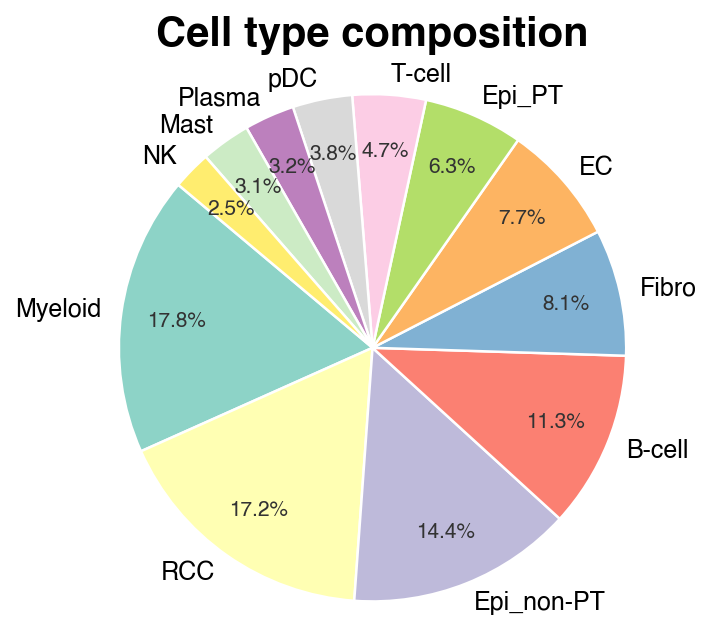

In [57]:
# ============================================================
# Pie chart of cell type proportions (publication style)
# ============================================================
proportions = adata_list[0].obsm['proportion'][cell_types].mean().sort_values(ascending=False)
palette = sns.color_palette('Set3', n_colors=len(proportions))

fig, ax = plt.subplots(figsize=(4.8, 4.8))

wedges, texts, autotexts = ax.pie(
    proportions,
    labels=proportions.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=palette,
    pctdistance=0.78,
    labeldistance=1.08,
    wedgeprops=dict(edgecolor='white', linewidth=1.2),
    textprops=dict(fontsize=12),
)

for at in autotexts:
    at.set_fontsize(10)
    at.set_color('#333333')
    #at.set_fontfamily('')

ax.set_title('Cell type composition', fontsize=20,
             fontweight='bold', pad=12) #fontfamily='Arial')
ax.axis('equal')

plt.savefig('cell_type_proportions.pdf', bbox_inches='tight', pad_inches=0.05)
plt.savefig('cell_type_proportions.png', bbox_inches='tight', pad_inches=0.05, dpi=300)
plt.show()

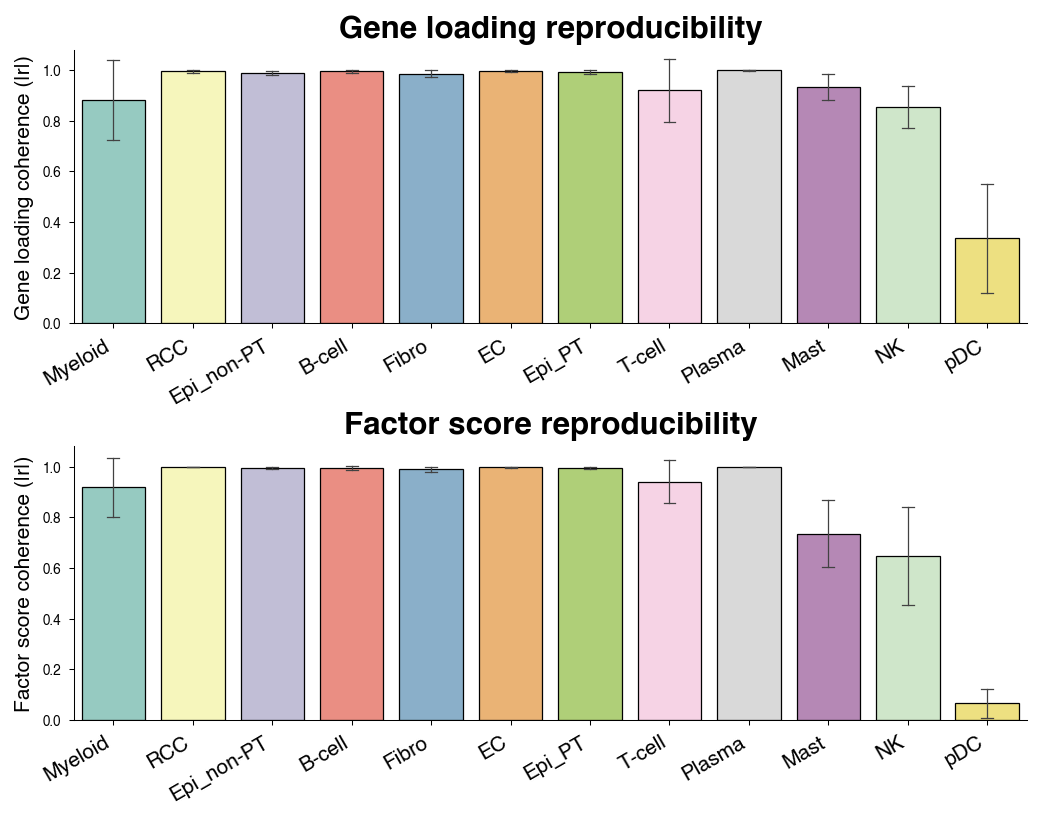

In [55]:
# ============================================================
# 绘图
# ============================================================
fig, axes = plt.subplots(
    2, 1,
    figsize=(8.2, 5.8),
    gridspec_kw={'hspace': 0.45}
)

#panel_labels = ['a', 'b']
titles = ['Gene loading reproducibility', 'Factor score reproducibility']
ylabels = ['Gene loading coherence (|r|)', 'Factor score coherence (|r|)']
dfs = [loading_df, factor_df]

palette = sns.color_palette('Set3', n_colors=n_ct)

for ax, df, title, ylabel in zip(axes, dfs, titles, ylabels):

    # --- Barplot (均值 + 95% CI) ---
    sns.barplot(
        data=df, x='Cell Type', y='Coherence',
        order=cell_types, ax=ax,
        palette=palette,
        edgecolor='black', linewidth=0.6,
        errorbar='sd', capsize=0.15,
        err_kws={'linewidth': 0.6},
    )

    ax.set_title(title, fontsize=15, fontweight='bold', pad=6)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xlabel('')
    ax.set_ylim(0, 1.08)
    ax.set_yticks(np.arange(0, 1.2, 0.2))

    ax.set_xticklabels(cell_types, rotation=30, ha='right', fontsize=10)

    # ax.text(
    #     -0.06, 1.12, label,
    #     transform=ax.transAxes,
    #     fontsize=10, fontweight='bold',
    #     va='top', ha='left'
    # )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

#axes[1].set_xlabel('Cell type', fontsize=10)

plt.savefig('reproducibility_random_init.pdf',
            bbox_inches='tight', pad_inches=0.05)
plt.savefig('reproducibility_random_init.png',
            bbox_inches='tight', pad_inches=0.05, dpi=300)
plt.show()

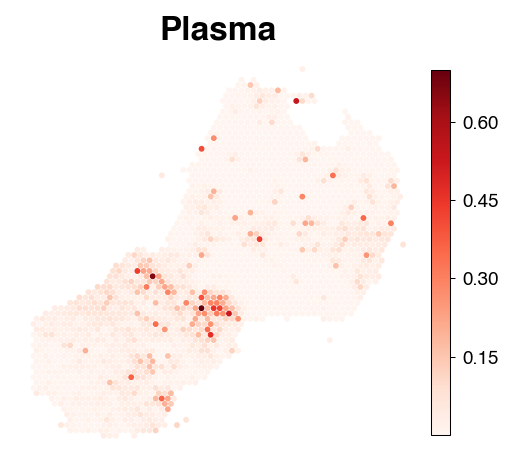

In [44]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.ticker import MaxNLocator

ct = 'Plasma'  
data = adata_result.obsm['proportion'][ct]

fig, ax = plt.subplots(figsize=(3.5, 3.2))

sc = ax.scatter(
    adata_result.obsm["spatial"][:, 0],
    -adata_result.obsm["spatial"][:, 1],
    c=data,
    s=8,
    cmap='Reds',
    linewidths=0
)
cb   = fig.colorbar(sc, ax=ax, shrink=0.85, pad=0.02)
cb.locator = MaxNLocator(nbins=5)
cb.update_ticks()
cb.ax.tick_params(labelsize=9)
# 去掉边框
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_linewidth(False)
ax.spines['bottom'].set_linewidth(False)

ax.set_title(ct, fontsize=16, fontweight='bold')
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

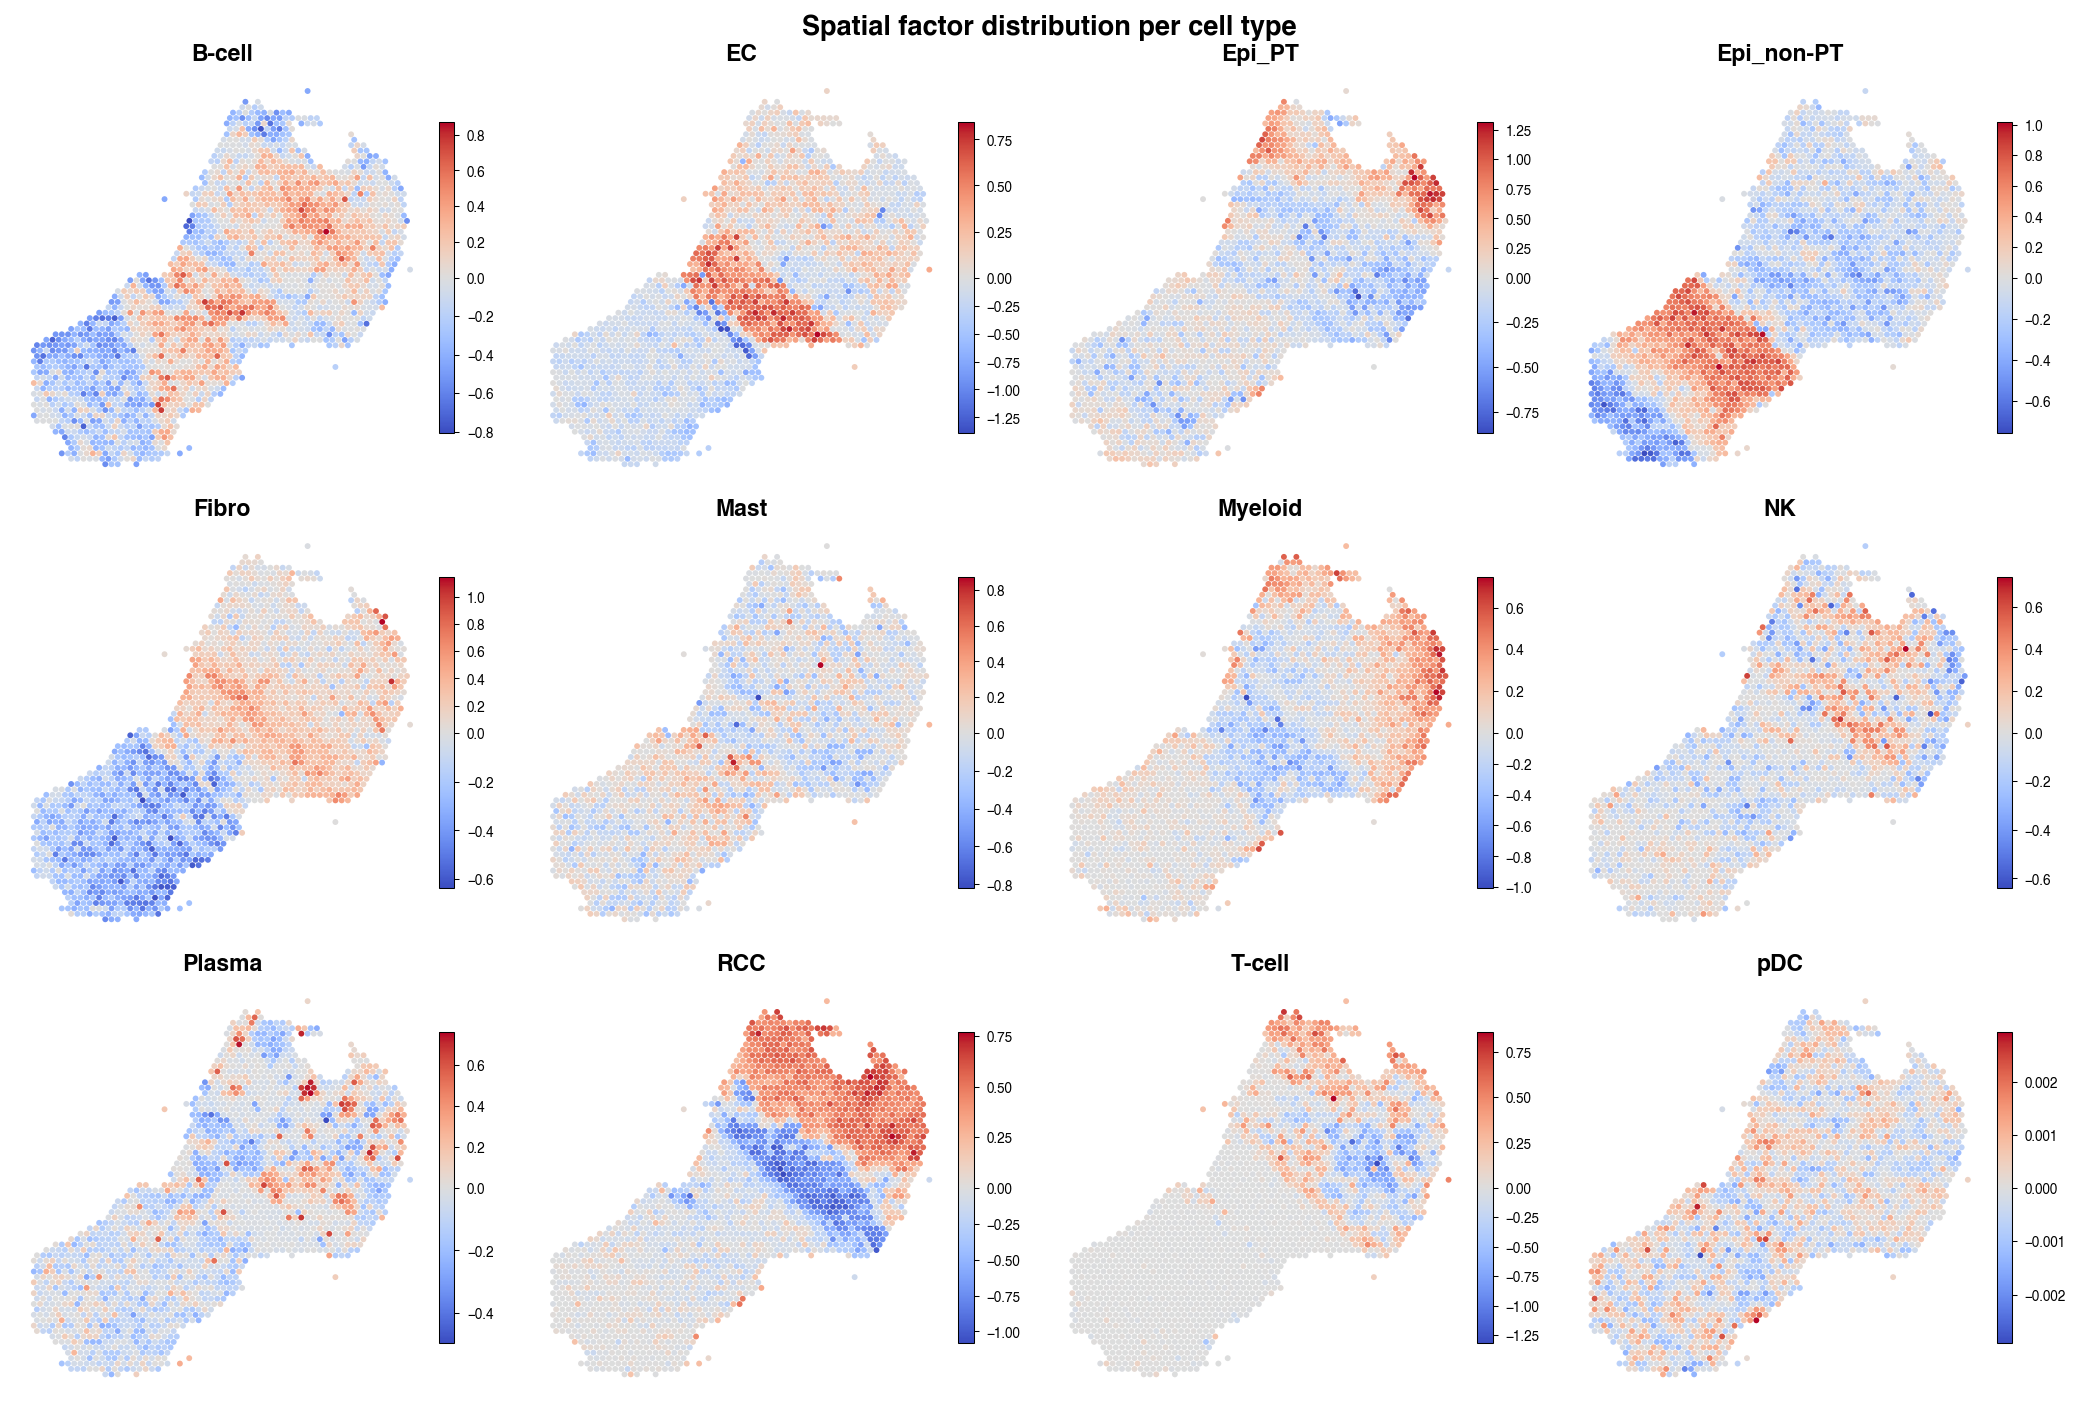

In [71]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

factors = adata_list[0].obsm['factor']
ct_names = list(factors.columns)
factor_mat = factors.values
spatial = adata_list[0].obsm['spatial']
x, y = spatial[:, 0], spatial[:, 1]

n_ct = len(ct_names)
ncols = 4
nrows = int(np.ceil(n_ct / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3.2))
axes = axes.flatten()

for i, ct in enumerate(ct_names):
    ax = axes[i]
    vec = factor_mat[:, i]
    vmax = np.percentile(np.abs(vec), 99)
    norm = TwoSlopeNorm(vcenter=0)
    sc = ax.scatter(x, -y, c=vec, cmap='coolwarm', norm=norm,
                    s=8, linewidths=0)#, rasterized=True)
    plt.colorbar(sc, ax=ax, shrink=0.7, pad=0.02)
    ax.set_title(ct, fontsize=11, fontweight='bold')
    ax.set_aspect('equal')
    ax.axis('off')

for j in range(n_ct, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Spatial factor distribution per cell type', fontsize=13, fontweight='bold')
plt.tight_layout()
#plt.savefig('factor_spatial.pdf', dpi=300, bbox_inches='tight')
plt.show()

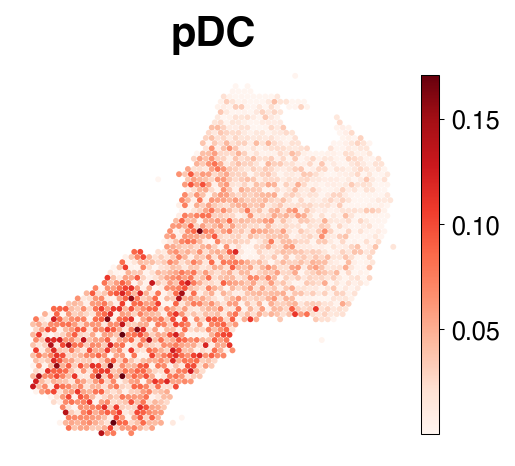

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.ticker import MaxNLocator

ct = 'pDC'  
data = adata_result.obsm['proportion'][ct]

fig, ax = plt.subplots(figsize=(3.5, 3.2))

sc = ax.scatter(
    adata_result.obsm["spatial"][:, 0],
    -adata_result.obsm["spatial"][:, 1],
    c=data,
    s=8,
    cmap='Reds',
    linewidths=0
)
cb   = fig.colorbar(sc, ax=ax, shrink=0.85, pad=0.02)
cb.locator = MaxNLocator(nbins=4)
cb.update_ticks()
cb.ax.tick_params(labelsize=12)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_linewidth(False)
ax.spines['bottom'].set_linewidth(False)

ax.set_title(ct, fontsize=20, fontweight='bold')
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

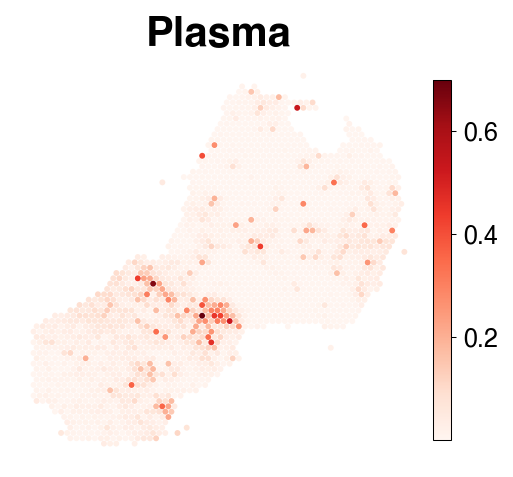

In [70]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.ticker import MaxNLocator

ct = 'Plasma'  
data = adata_list[0].obsm['proportion'][ct]

fig, ax = plt.subplots(figsize=(3.5, 3.2))

sc = ax.scatter(
    adata_result.obsm["spatial"][:, 0],
    -adata_result.obsm["spatial"][:, 1],
    c=data,
    s=8,
    cmap='Reds',
    linewidths=0
)
cb   = fig.colorbar(sc, ax=ax, shrink=0.85, pad=0.02)
cb.locator = MaxNLocator(nbins=4)
cb.update_ticks()
cb.ax.tick_params(labelsize=12)
# 去掉边框
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_linewidth(False)
ax.spines['bottom'].set_linewidth(False)

ax.set_title(ct, fontsize=20, fontweight='bold')
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

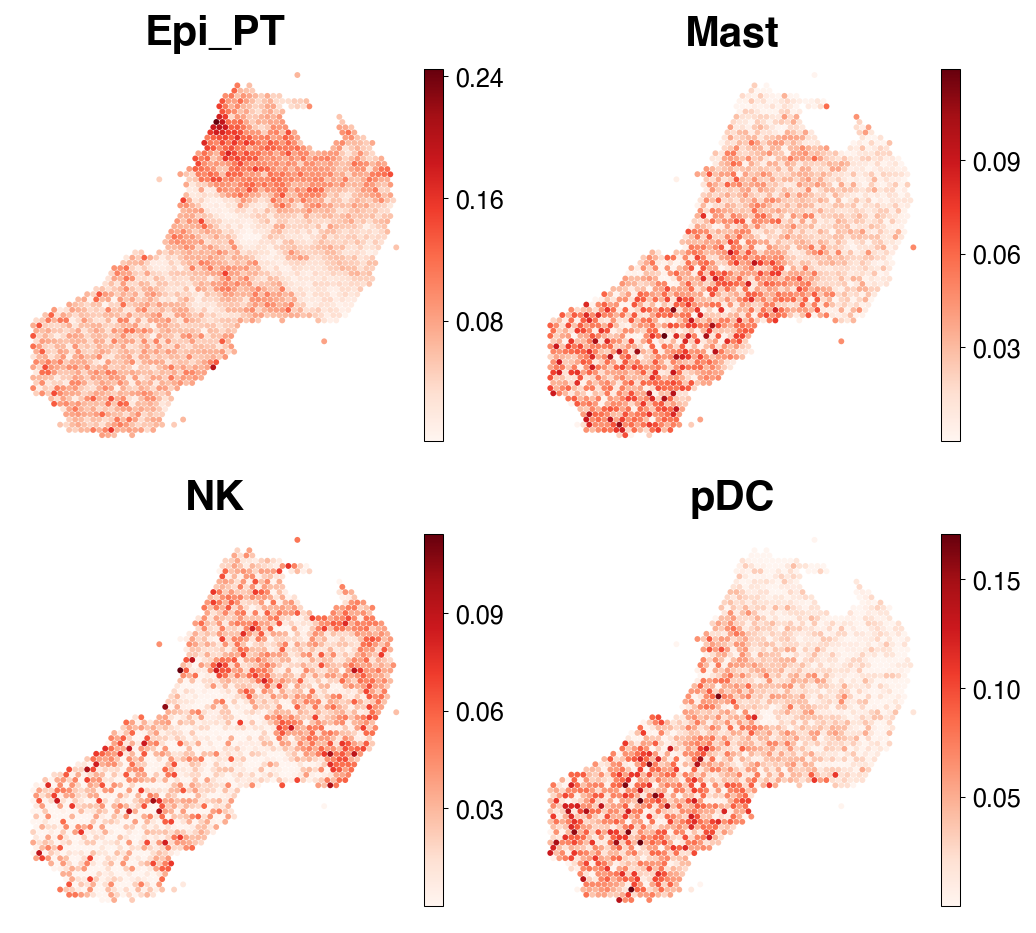

In [72]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.ticker import MaxNLocator

ct_rare = ['Epi_PT', 'Mast', 'NK', 'pDC']


fig, axes = plt.subplots(2, 2, figsize=(3.5*2, 3.2*2))
for i, ax in enumerate(axes.flat):
    ct = ct_rare[i]
    data = adata_result.obsm['proportion'][ct]
    sc = ax.scatter(
        adata_result.obsm["spatial"][:, 0],
        -adata_result.obsm["spatial"][:, 1],
        c=data,
        s=8,
        cmap='Reds',
        linewidths=0
    )
    cb = fig.colorbar(sc, ax=ax, shrink=0.85, pad=0.02)
    cb.locator = MaxNLocator(nbins=4)
    cb.update_ticks()
    cb.ax.tick_params(labelsize=12)
    # 去掉边框

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_linewidth(False)
    ax.spines['bottom'].set_linewidth(False)

    ax.set_title(ct, fontsize=20, fontweight='bold')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()